In [2]:
import os
import pandas as pd

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')
billboard_data_filepath = os.path.join(data_dir, 'billboard.csv')

# Load Data.
billboard = pd.read_csv(billboard_data_filepath, encoding='latin1')

# Display the first few rows and column names.
display(billboard.head())
print(f"Columns: {billboard.columns.tolist()}")

,artist,track,date.entered,wk1,wk2,wk3,wk4,wk5,wk6,wk7,...,wk67,wk68,wk69,wk70,wk71,wk72,wk73,wk74,wk75,wk76
0,2 Pac,Baby Don't Cry (Keep...,2000-02-26,87,82.0,72.0,77.0,87.0,94.0,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2Ge+her,The Hardest Part Of ...,2000-09-02,91,87.0,92.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3 Doors Down,Kryptonite,2000-04-08,81,70.0,68.0,67.0,66.0,57.0,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3 Doors Down,Loser,2000-10-21,76,76.0,72.0,69.0,67.0,65.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,504 Boyz,Wobble Wobble,2000-04-15,57,34.0,25.0,17.0,17.0,31.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns: ['artist', 'track', 'date.entered', 'wk1', 'wk2', 'wk3', 'wk4', 'wk5', 'wk6', 'wk7', 'wk8', 'wk9', 'wk10', 'wk11', 'wk12', 'wk13', 'wk14', 'wk15', 'wk16', 'wk17', 'wk18', 'wk19', 'wk20', 'wk21', 'wk22', 'wk23', 'wk24', 'wk25', 'wk26', 'wk27', 'wk28', 'wk29', 'wk30', 'wk31', 'wk32', 'wk33', 'wk34', 'wk35', 'wk36', 'wk37', 'wk38', 'wk39', 'wk40', 'wk41', 'wk42', 'wk43', 'wk44', 'wk45', 'wk46', 'wk47', 'wk48', 'wk49', 'wk50', 'wk51', 'wk52', 'wk53', 'wk54', 'wk55', 'wk56', 'wk57', 'wk58', 'wk59', 'wk60', 'wk61', 'wk62', 'wk63', 'wk64', 'wk65', 'wk66', 'wk67', 'wk68', 'wk69', 'wk70', 'wk71', 'wk72', 'wk73', 'wk74', 'wk75', 'wk76']


### Create `week` column
Create `week` column by pivoting `wk1`, `wk2`, ... columns into rows.

In [3]:
# Fix Dataset
billboard = billboard.melt(
    id_vars=["artist", "track", "date.entered"],
    var_name="week",
    value_name="rank")

# Display the first few rows and column names.
display(billboard.head())
print(f"Columns: {billboard.columns.tolist()}")

,artist,track,date.entered,week,rank
0,2 Pac,Baby Don't Cry (Keep...,2000-02-26,wk1,87.0
1,2Ge+her,The Hardest Part Of ...,2000-09-02,wk1,91.0
2,3 Doors Down,Kryptonite,2000-04-08,wk1,81.0
3,3 Doors Down,Loser,2000-10-21,wk1,76.0
4,504 Boyz,Wobble Wobble,2000-04-15,wk1,57.0


Columns: ['artist', 'track', 'date.entered', 'week', 'rank']


## Part a. Tidy Data
`parse_number(week)` extracts the numeric part from values, converting them from strings to numbers. The line `mutate(week = parse_number(week))` is needed because `week` is initially stored as text, but it represents a numeric variable. Converting values to integers or floats allows sorting, comparison, and more. If this line is skipped, `week` remains a string, and numeric operations will fail.

In [4]:
# Python Code
billboard["week"] = billboard["week"].str.extract(r"(\d+)").astype(int)
print(f"Values of week column: {billboard['week'].unique()}\n")

Values of week column: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76]



## Part b. Pivot
With `values_drop_na = TRUE`, all rows where the pivoted value is `NA` are removed. In python, the equivalent is `billboard.dropna(subset=["rank"])`. Rows are only removed when their `rank` value is `NaN`, while missing values in other columns are ignored. Only `rank` is checked because this is the value column created by `melt()`, and its missing values represent weeks when a song was not on the chart. Other columns contain information we want to keep, so missing values there should not determine whether a row is removed.

In [5]:
before = len(billboard)
billboard = billboard.dropna(subset=["rank"])
after = len(billboard)
print(f"Number of entries removed: {before - after}")

Number of entries removed: 18785


## Part c. Missing weeks
An explicit missing value is a value directly recorded as missing, such as `NaN`. An implicit missing value is absent. For the `billboard` dataset, we can find implicit missing data by checking which weeks are absent for a given song. `groupby()` groups rows by song, `set(x)` gets the weeks that actually appear. `expected_weeks - set(x)` finds weeks that are missing. `sorted(...)` puts missing weeks in order, and `.apply` performs this for every song. The print statement filters the results to only songs that have at least one missing week.

In [6]:
expected_weeks = set(range(1, 77))
implicit_missing = (
    billboard.groupby(['artist', 'track'])['week']
    .apply(lambda x: sorted(expected_weeks - set(x))))

print(f"Implicit missing:\n{implicit_missing[implicit_missing.apply(len) > 0]}")

Implicit missing:
artist            track                  
2 Pac             Baby Don't Cry (Keep...    [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,...
2Ge+her           The Hardest Part Of ...    [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...
3 Doors Down      Kryptonite                 [54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 6...
                  Loser                      [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...
504 Boyz          Wobble Wobble              [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...
                                                                   ...                        
Yankee Grey       Another Nine Minutes       [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...
Yearwood, Trisha  Real Live Woman            [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
Ying Yang Twins   Whistle While You Tw...    [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2...
Zombie Nation     Kernkraft 400              [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14

## Part d. Variable Types

In [7]:
print(f"Variable Types:\n{billboard.dtypes}")

Variable Types:
artist              str
track               str
date.entered        str
week              int64
rank            float64
dtype: object


Overall, the variables are appropriately typed. However, `date.entered` could be typed as a datetime rather than a string. This is preferable if we need to sort or filter based on date.

In [9]:
billboard["date.entered"] = pd.to_datetime(billboard["date.entered"])
print(f"Datetime Type: {billboard['date.entered'].dtype}")

Datetime Type: datetime64[us]


## Part e. Visualization
### Top Songs by weeks spent in the top 10
This visualization shows the 10 songs that spent the most weeks ranked in the top 10. The goal is to investigate which songs are the most popular. The x-axis is limited to emphasize the comparison between top songs. `billboard['rank'] <= 10` keeps only weeks where a song is in the top 10. We then group the data by each individual song, and `.size()` counts how many top-10 weeks each song has. `.head(10)` keeps the top 10 songs.

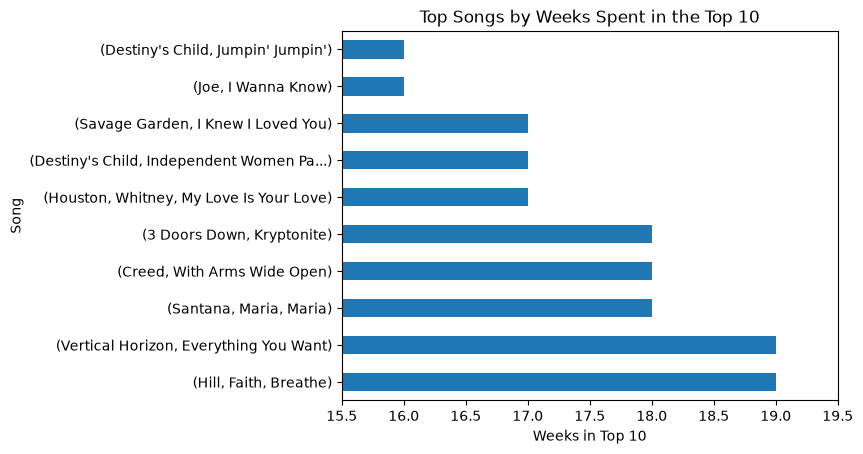

In [31]:
import matplotlib.pyplot as plt

top_songs = (
    billboard[billboard["rank"] <= 10]
    .groupby(["artist", "track"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_songs.plot(kind="barh")
plt.xlim(15.5, 19.5)
plt.xlabel("Weeks in Top 10")
plt.ylabel("Song")
plt.title("Top Songs by Weeks Spent in the Top 10")
plt.show()

### Top artists by weeks spent with a song in the top 10
This visualization shows the 10 artists whose songs collectively spend the most weeks in the top 10. The goal is to investigate which artists are the most popular. Instead of grouping by individual song, we group by artist. Again, the x-axis is limited to make the comparison more clear. The visualization shows that artist Destiny's Child significantly outperforms other artists according to this ranking method.

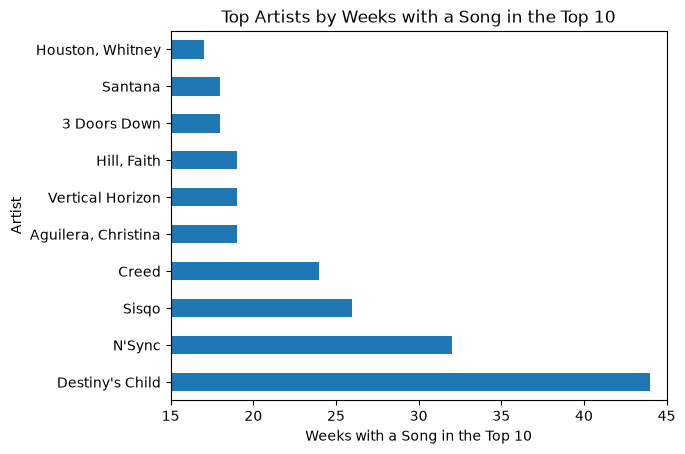

In [28]:
top_artists = (
    billboard[billboard["rank"] <= 10]
    .groupby("artist")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_artists.plot(kind="barh")
plt.xlim(15, 45)
plt.xlabel("Weeks with a Song in the Top 10")
plt.ylabel("Artist")
plt.title("Top Artists by Weeks with a Song in the Top 10")
plt.show()

## Part f. Line Plot
This visualization tracks the weekly chart rank of each Destiny's Child song. First, we filter the dataset to Destiny's Child songs. Then, we group the songs individually. The inverted y-axis places rank 1 at the top, making it easier to see when each song reached its peak and how its rank changed over time. We plot each song's rank across weeks, with each song as a separate line. Each line follows a similar curve shape, while "Indenpendent Women" climbed the rankings most quickly. Interestingly, 'Say My Name' dipped briefly in the rankings before climbing again, possibly because other competing songs became popular at the same time.

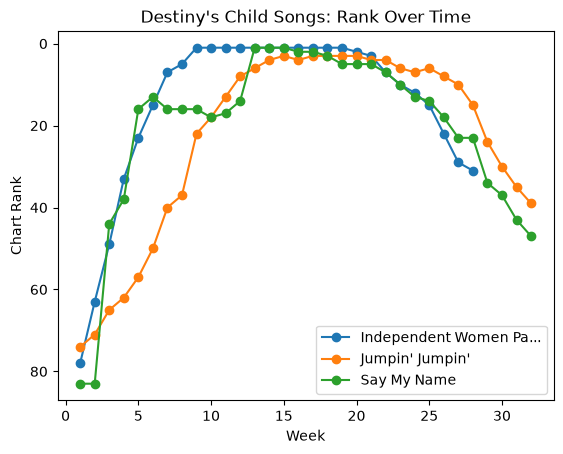

In [32]:
destinys_child = billboard[billboard["artist"] == "Destiny's Child"]

for song, data in destinys_child.groupby("track"):
    plt.plot(data["week"], data["rank"], marker="o", label=song)

plt.gca().invert_yaxis()  # Rank 1 appears at the top
plt.xlabel("Week")
plt.ylabel("Chart Rank")
plt.title("Destiny's Child Songs: Rank Over Time")
plt.legend()
plt.show()

## Bar Plot Songs per Artists

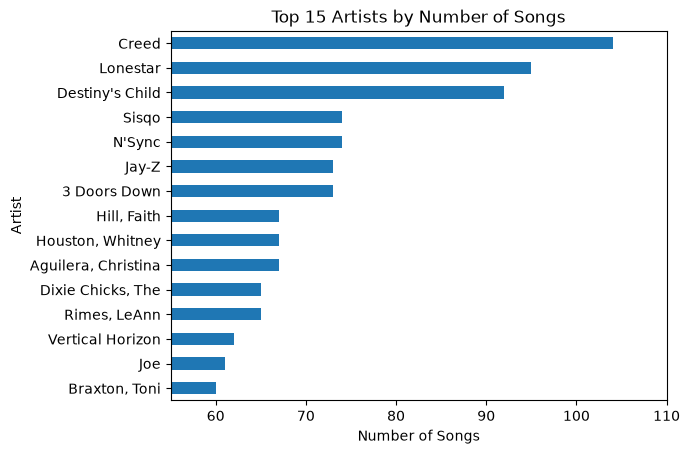

In [35]:
import matplotlib.pyplot as plt

top_artists = billboard["artist"].value_counts().head(15)

top_artists.sort_values().plot(kind="barh")

plt.xlim(55, 110)
plt.xlabel("Number of Songs")
plt.ylabel("Artist")
plt.title("Top 15 Artists by Number of Songs")
plt.show()

Destiny's Child is in the top three artists by number of songs. This makes sense as Destiny's Child was the top artist for time spent with a song ranked in the top ten. Creed and Lonestar overall had more songs in the top 100. This shows that it is difficult to define the best artist. The way artists are ranked drastically changes which artists are ranked the best.

## Part h. Quarterly Revenue Dataset
### Load Data

In [7]:
import os
import pandas as pd

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'data')
revenue_data_filepath = os.path.join(data_dir, 'RevQtr.csv')

# Load Data.
revenue = pd.read_csv(revenue_data_filepath, encoding='latin1')
revenue = revenue.rename(columns={"ï»¿Group": "Group"})

# Display the first few rows and column names.
display(revenue.head())
print(f"Columns: {revenue.columns.tolist()}")

,Group,Year,Qtr.1,Qtr.2,Qtr_3,Qtr.4
0,1,2022,61,24,81,70
1,1,2023,30,92,96,84
2,1,2024,84,97,33,12
3,2,2022,31,62,11,97
4,2,2023,39,47,11,73


Columns: ['Group', 'Year', 'Qtr.1', 'Qtr.2', 'Qtr_3', 'Qtr.4']


### Restructure and tidy the data
`revenue.melt(...)` converts the quarter columns into rows while keeping 'Group' and 'Year'. `var_name="Interval_Type"` stores the original column names (e.g., Qtr1, Qtr2). `value_name`="Revenue" stores the corresponding revenue values. `str.extract(r"(\d+)")` extracts the number from Qtr1, Qtr2, ect.. creating `Interval_ID`. `revenue_long["Interval_Type"] = "Qtr"` changes every interval type to "Qtr". 

In [9]:
revenue_long = revenue.melt(
    id_vars=["Group", "Year"],
    var_name="Interval_Type",
    value_name="Revenue")

revenue_long["Interval_ID"] = (revenue_long["Interval_Type"].str.extract(r"(\d+)").astype(int))
revenue_long["Interval_Type"] = "Qtr"
revenue_long = revenue_long[["Group", "Year", "Interval_Type", "Interval_ID", "Revenue"]]

# Display
display(revenue_long.head())
print(f"Columns: {revenue_long.columns.tolist()}\n")

,Group,Year,Interval_Type,Interval_ID,Revenue
0,1,2022,Qtr,1,61
1,1,2023,Qtr,1,30
2,1,2024,Qtr,1,84
3,2,2022,Qtr,1,31
4,2,2023,Qtr,1,39


Columns: ['Group', 'Year', 'Interval_Type', 'Interval_ID', 'Revenue']



In [10]:
print(f"Number of rows in new dataset: {revenue_long.shape[0]}")

Number of rows in new dataset: 48
